In [3]:
import pandas as pd

In [4]:
df=pd.read_csv(r'D:\python folders\data.csv')
df

,Duration,Date,Pulse,Maxpulse,Calories
0,60,01-12-2020,110,130,409.1
1,60,02-12-2020,117,145,479.0
2,60,03-12-2020,103,135,340.0
3,45,04-12-2020,109,175,282.4
4,45,05-12-2020,117,148,406.0
5,60,06-12-2020,102,127,300.0
6,60,07-12-2020,110,136,374.0
7,450,08-12-2020,104,134,253.3
8,30,09-12-2020,109,133,195.1
9,60,10-12-2020,98,124,269.0


In [5]:
# First We will check how many columns there are and the shape so we will know how many rows and columns there are and use info to see the details
df.columns

Index(['Duration', 'Date', 'Pulse', 'Maxpulse', 'Calories'], dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Duration  32 non-null     int64  
 1   Date      31 non-null     str    
 2   Pulse     32 non-null     int64  
 3   Maxpulse  32 non-null     int64  
 4   Calories  30 non-null     float64
dtypes: float64(1), int64(3), str(1)
memory usage: 1.4 KB


In [7]:
df.shape

(32, 5)

In [8]:
# As we can see some columns in Duration and Calories are missing or null values the calories contain values from 100 to upto 400 so the best approach
# will be that we fill the null Values with the mean as there are no outliers
df.Calories

0     409.1
1     479.0
2     340.0
3     282.4
4     406.0
5     300.0
6     374.0
7     253.3
8     195.1
9     269.0
10    329.3
11    250.7
12    250.7
13    345.3
14    379.3
15    275.0
16    215.2
17    300.0
18      NaN
19    323.0
20    243.0
21    364.2
22    282.0
23    300.0
24    246.0
25    334.5
26    250.0
27    241.0
28      NaN
29    280.0
30    380.3
31    243.0
Name: Calories, dtype: float64

In [9]:
import numpy as np

In [10]:
x= df['Calories'].mean()
x

np.float64(304.68)

In [11]:
df.fillna({'Calories':x},inplace=True)
df

,Duration,Date,Pulse,Maxpulse,Calories
0,60,01-12-2020,110,130,409.10
1,60,02-12-2020,117,145,479.00
2,60,03-12-2020,103,135,340.00
3,45,04-12-2020,109,175,282.40
4,45,05-12-2020,117,148,406.00
5,60,06-12-2020,102,127,300.00
6,60,07-12-2020,110,136,374.00
7,450,08-12-2020,104,134,253.30
8,30,09-12-2020,109,133,195.10
9,60,10-12-2020,98,124,269.00


In [12]:
df['Duration'].mean()

np.float64(68.4375)

In [13]:
import matplotlib.pyplot as plt
import numpy as np

AttributeError: 'DataFrame' object has no attribute 'show'

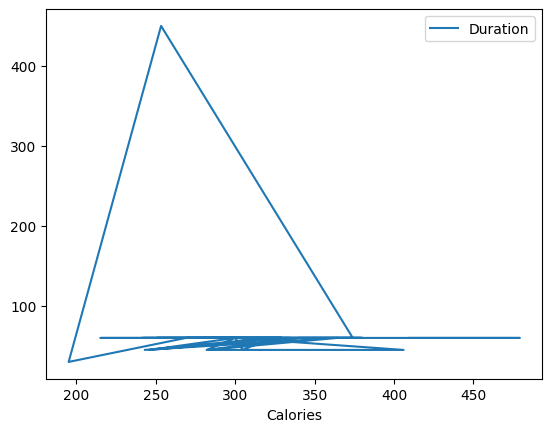

In [14]:
df.plot( kind='line', x = 'Calories', y = 'Duration')
df.show()

In [ ]:
#The above chart is showing the outlier in Duration but we cannot understand it clearly so let's make another
# one for calories and Duration both
df.plot( kind='line', y = 'Calories')
df.plot( kind='line', y = 'Duration')
df.show()

In [ ]:
x= max(df['Calories'])
y=min(df['Calories'])
x,y


In [ ]:
z=x-y
print("The mean of Calories is 304 and range is",z)

In [15]:
p=df['Duration'].mean()
x= max(df['Duration'])
y=min(df['Duration'])
x,y,p

(450, 30, np.float64(68.4375))

In [16]:
z=x-y
print("The mean of Duration is 68 and the range is",z)

The mean of Duration is 68 and the range is 420


In [17]:

#As you can see the differnce and mean in Calories are just little apart but in
#Duration the diffence between min and max and the mean is too large it indicates that there 
#is an outlier in the data is small so i already noticed it but if the data is large 
#then we would had to use this method to find outlier or else there is one more method to 
#find outlier that is using Quantile method.




In [18]:
Q1 = df['Duration'].quantile(0.25)
Q3 = df['Duration'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [19]:
outliers = df[(df['Duration'] < lower) | (df['Duration'] > upper)]

In [20]:
outliers.shape[0]

8

In [21]:
outliers['Duration']

3      45
4      45
7     450
8      30
18     45
20     45
22     45
24     45
Name: Duration, dtype: int64

In [22]:
# It seems that row no. 7 was misprint as 450 so we will change it to 45
df.loc[7,'Duration']=45

In [23]:
df

,Duration,Date,Pulse,Maxpulse,Calories
0,60,01-12-2020,110,130,409.10
1,60,02-12-2020,117,145,479.00
2,60,03-12-2020,103,135,340.00
3,45,04-12-2020,109,175,282.40
4,45,05-12-2020,117,148,406.00
5,60,06-12-2020,102,127,300.00
6,60,07-12-2020,110,136,374.00
7,45,08-12-2020,104,134,253.30
8,30,09-12-2020,109,133,195.10
9,60,10-12-2020,98,124,269.00


In [24]:
# Now it comes to Date 
df['Date'].dtype

<StringDtype(storage='python', na_value=nan)>

In [25]:
def myconv(a):
    try:
        if str(a).isdigit():
            return pd.to_datetime(int(a),unit='D',origin='1899-12-30')
        else:
            return pd.to_datetime(a,dayfirst=True)
    except:
        pd.NaT
        

In [26]:
df['Date']=df['Date'].apply(myconv)

In [27]:
df

,Duration,Date,Pulse,Maxpulse,Calories
0,60,2020-12-01,110,130,409.10
1,60,2020-12-02,117,145,479.00
2,60,2020-12-03,103,135,340.00
3,45,2020-12-04,109,175,282.40
4,45,2020-12-05,117,148,406.00
5,60,2020-12-06,102,127,300.00
6,60,2020-12-07,110,136,374.00
7,45,2020-12-08,104,134,253.30
8,30,2020-12-09,109,133,195.10
9,60,2020-12-10,98,124,269.00


In [28]:
# Now only the missing date Nat is left as we already know what date will come so 
#we can simply write a code that is df.loc[22,'Date']= '2020-12-22' but 
#we Cannot find all Nat and replace so we will use the interpolate function

df['Date'] = df['Date'].interpolate()

In [29]:
df

,Duration,Date,Pulse,Maxpulse,Calories
0,60,2020-12-01,110,130,409.10
1,60,2020-12-02,117,145,479.00
2,60,2020-12-03,103,135,340.00
3,45,2020-12-04,109,175,282.40
4,45,2020-12-05,117,148,406.00
5,60,2020-12-06,102,127,300.00
6,60,2020-12-07,110,136,374.00
7,45,2020-12-08,104,134,253.30
8,30,2020-12-09,109,133,195.10
9,60,2020-12-10,98,124,269.00


In [30]:
df.loc[20:24,'Date']

20   2020-12-20
21   2020-12-21
22   2020-12-22
23   2020-12-23
24   2020-12-24
Name: Date, dtype: datetime64[us]

In [31]:
# Now its done clean and structured

In [32]:
import pandas as pd

In [33]:
df.drop_duplicates()

,Duration,Date,Pulse,Maxpulse,Calories
0,60,2020-12-01,110,130,409.10
1,60,2020-12-02,117,145,479.00
2,60,2020-12-03,103,135,340.00
3,45,2020-12-04,109,175,282.40
4,45,2020-12-05,117,148,406.00
5,60,2020-12-06,102,127,300.00
6,60,2020-12-07,110,136,374.00
7,45,2020-12-08,104,134,253.30
8,30,2020-12-09,109,133,195.10
9,60,2020-12-10,98,124,269.00
